In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

pd.set_option("display.max_columns", None)
df_2021 = pd.read_csv("./Data/2021.csv")
df_2022 = pd.read_csv("./Data/2022.csv")
df_2023 = pd.read_csv("./Data/2023.csv")
df = pd.concat([df_2021, df_2022, df_2023])
df

,Rk,Gcar,Gtm,Date,Team,Unnamed: 5,Opp,Result,Inngs,PA,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,BA,OBP,SLG,OPS,TB,GIDP,HBP,SH,SF,ROE,IBB,BAbip,aLI,WPA,acLI,cWPA,RE24,BOP,Pos
0,1.0,267.0,1.0,2021-04-01,LAA,NaN,CHW,W 4-3,CG,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.73,0.058,1.62,0.03%,0.02,2.0,DH
1,2.0,268.0,2.0,2021-04-02,LAA,NaN,CHW,L 8-12,CG,5.0,5.0,2.0,2.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,3.0,0.222,0.222,0.778,1.000,7.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000,0.90,-0.037,0.89,-0.02%,1.64,2.0,DH
2,3.0,269.0,3.0,2021-04-03,LAA,NaN,CHW,W 5-3,CG,4.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.231,0.231,0.615,0.846,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,1.38,-0.031,1.31,-0.02%,-0.33,2.0,DH
3,4.0,270.0,4.0,2021-04-04,LAA,NaN,CHW,W 7-4,GS-5,3.0,3.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.250,0.250,0.750,1.000,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.70,0.055,0.68,0.03%,0.23,2.0,P
4,5.0,271.0,5.0,2021-04-05,LAA,NaN,HOU,W 7-6,8-9,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.250,0.294,0.750,1.044,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,4.26,0.151,4.98,0.11%,0.84,8.0,PH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,132.0,713.0,134.0,2023-08-30,LAA,@,PHI,W 10-8,CG,5.0,4.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0.307,0.410,0.661,1.071,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.500,1.63,0.032,0.00,0.00%,0.31,3.0,DH
132,133.0,714.0,135.0,2023-09-01,LAA,@,OAK,L 2-9,CG,4.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.307,0.411,0.661,1.072,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333,0.78,-0.033,0.00,0.00%,0.19,3.0,DH
133,134.0,715.0,136.0,2023-09-02,LAA,@,OAK,L 1-2,CG,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.306,0.413,0.658,1.070,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.000,2.50,0.014,0.01,0.00%,0.27,2.0,DH
134,135.0,716.0,137.0,2023-09-03,LAA,@,OAK,L 6-10,CG,5.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,0.304,0.412,0.654,1.066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.57,-0.007,0.00,0.00%,0.06,2.0,DH


In [2]:
df.columns = [x.lower() for x in df.columns]
df = df.rename(columns={"unnamed: 5": "home"})
df["home"] = df["home"] != "@"
df["nibb"] = df["bb"] - df["ibb"]
df["pitching"] = df["pos"].astype(str).apply(lambda x: "P" in x.split())
# drop the average columns
df = df[df["pa"] >= 3]
df["1b"] = df["h"] - (df["2b"] + df["3b"] + df["hr"])
df_averages = df.copy()[df["rk"].isna()]
df = df.dropna(subset="rk")
df

,rk,gcar,gtm,date,team,home,opp,result,inngs,pa,ab,r,h,2b,3b,hr,rbi,sb,cs,bb,so,ba,obp,slg,ops,tb,gidp,hbp,sh,sf,roe,ibb,babip,ali,wpa,acli,cwpa,re24,bop,pos,nibb,pitching,1b
0,1.0,267.0,1.0,2021-04-01,LAA,True,CHW,W 4-3,CG,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.73,0.058,1.62,0.03%,0.02,2.0,DH,0.0,False,0.0
1,2.0,268.0,2.0,2021-04-02,LAA,True,CHW,L 8-12,CG,5.0,5.0,2.0,2.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,3.0,0.222,0.222,0.778,1.000,7.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000,0.90,-0.037,0.89,-0.02%,1.64,2.0,DH,0.0,False,0.0
2,3.0,269.0,3.0,2021-04-03,LAA,True,CHW,W 5-3,CG,4.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.231,0.231,0.615,0.846,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,1.38,-0.031,1.31,-0.02%,-0.33,2.0,DH,0.0,False,1.0
3,4.0,270.0,4.0,2021-04-04,LAA,True,CHW,W 7-4,GS-5,3.0,3.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.250,0.250,0.750,1.000,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.70,0.055,0.68,0.03%,0.23,2.0,P,0.0,True,0.0
5,6.0,272.0,6.0,2021-04-06,LAA,True,HOU,L 2-4,CG,4.0,4.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.300,0.333,0.700,1.033,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.99,0.006,1.23,0.00%,0.06,2.0,DH,0.0,False,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,131.0,712.0,133.0,2023-08-29,LAA,False,PHI,L 7-12,CG,5.0,5.0,0.0,3.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.307,0.410,0.664,1.074,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.600,1.05,0.087,0.01,0.00%,1.60,2.0,DH,0.0,False,2.0
131,132.0,713.0,134.0,2023-08-30,LAA,False,PHI,W 10-8,CG,5.0,4.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0.307,0.410,0.661,1.071,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.500,1.63,0.032,0.00,0.00%,0.31,3.0,DH,1.0,False,1.0
132,133.0,714.0,135.0,2023-09-01,LAA,False,OAK,L 2-9,CG,4.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.307,0.411,0.661,1.072,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333,0.78,-0.033,0.00,0.00%,0.19,3.0,DH,1.0,False,0.0
133,134.0,715.0,136.0,2023-09-02,LAA,False,OAK,L 1-2,CG,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.306,0.413,0.658,1.070,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.000,2.50,0.014,0.01,0.00%,0.27,2.0,DH,1.0,False,0.0


In [3]:
def calculate_woba(df):
    # wOBA weights for 2021
    weights = {
        "nibb": 0.69,
        "hbp": 0.722,
        "1b": 0.881,
        "2b": 1.257,
        "3b": 1.593,
        "hr": 2.058,
    }

    # numerator
    numerator = (
        df["nibb"] * weights["nibb"]
        + df["hbp"] * weights["hbp"]
        + df["1b"] * weights["1b"]
        + df["2b"] * weights["2b"]
        + df["3b"] * weights["3b"]
        + df["hr"] * weights["hr"]
    )

    # denominator
    denominator = df["ab"] + df["bb"] - df["ibb"] + df["sf"] + df["hbp"]
    return numerator / denominator


# wOBA calculation
df["woba"] = calculate_woba(df)
df

,rk,gcar,gtm,date,team,home,opp,result,inngs,pa,ab,r,h,2b,3b,hr,rbi,sb,cs,bb,so,ba,obp,slg,ops,tb,gidp,hbp,sh,sf,roe,ibb,babip,ali,wpa,acli,cwpa,re24,bop,pos,nibb,pitching,1b,woba
0,1.0,267.0,1.0,2021-04-01,LAA,True,CHW,W 4-3,CG,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.73,0.058,1.62,0.03%,0.02,2.0,DH,0.0,False,0.0,0.00000
1,2.0,268.0,2.0,2021-04-02,LAA,True,CHW,L 8-12,CG,5.0,5.0,2.0,2.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,3.0,0.222,0.222,0.778,1.000,7.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000,0.90,-0.037,0.89,-0.02%,1.64,2.0,DH,0.0,False,0.0,0.73020
2,3.0,269.0,3.0,2021-04-03,LAA,True,CHW,W 5-3,CG,4.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.231,0.231,0.615,0.846,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,1.38,-0.031,1.31,-0.02%,-0.33,2.0,DH,0.0,False,1.0,0.22025
3,4.0,270.0,4.0,2021-04-04,LAA,True,CHW,W 7-4,GS-5,3.0,3.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.250,0.250,0.750,1.000,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.70,0.055,0.68,0.03%,0.23,2.0,P,0.0,True,0.0,0.68600
5,6.0,272.0,6.0,2021-04-06,LAA,True,HOU,L 2-4,CG,4.0,4.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.300,0.333,0.700,1.033,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.99,0.006,1.23,0.00%,0.06,2.0,DH,0.0,False,2.0,0.44050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,131.0,712.0,133.0,2023-08-29,LAA,False,PHI,L 7-12,CG,5.0,5.0,0.0,3.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.307,0.410,0.664,1.074,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.600,1.05,0.087,0.01,0.00%,1.60,2.0,DH,0.0,False,2.0,0.60380
131,132.0,713.0,134.0,2023-08-30,LAA,False,PHI,W 10-8,CG,5.0,4.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0.307,0.410,0.661,1.071,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.500,1.63,0.032,0.00,0.00%,0.31,3.0,DH,1.0,False,1.0,0.31420
132,133.0,714.0,135.0,2023-09-01,LAA,False,OAK,L 2-9,CG,4.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.307,0.411,0.661,1.072,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333,0.78,-0.033,0.00,0.00%,0.19,3.0,DH,1.0,False,0.0,0.48675
133,134.0,715.0,136.0,2023-09-02,LAA,False,OAK,L 1-2,CG,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.306,0.413,0.658,1.070,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.000,2.50,0.014,0.01,0.00%,0.27,2.0,DH,1.0,False,0.0,0.23000


In [4]:
pitching = df.loc[df["pitching"]]
not_pitching = df.loc[~df["pitching"]]
pitching.shape, not_pitching.shape

((68, 44), (363, 44))

In [5]:
# t test
p = pitching["woba"]
not_p = not_pitching["woba"]
mean_diff = p.mean() - not_p.mean()
se = np.sqrt(p.var() / p.shape[0] + not_p.var() / not_p.shape[0])
t_stat = mean_diff / se
degrees_freedom = p.shape[0] - 1
p_val = 2 * stats.t.cdf(-abs(t_stat), degrees_freedom)

# CI
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, degrees_freedom)
ci_lower = mean_diff - t_crit * se
ci_upper = mean_diff + t_crit * se

print(f"t = {t_stat:.3f}, p = {p_val:.3f}, df = {degrees_freedom:.1f}")
print(f"95% CI = ({ci_lower:.3f}, {ci_upper:.3f})")

t = -0.381, p = 0.704, df = 67.0
95% CI = (-0.103, 0.070)


In [6]:
mean_diff, se

(-0.016542701171377683, 0.04338685507066898)

In [7]:
print(stats.ttest_ind(p, not_p, equal_var=False))
print(stats.t.interval(0.95, degrees_freedom, loc=mean_diff, scale=se))

TtestResult(statistic=-0.3812837124154943, pvalue=0.7039248636619351, df=86.76043331428532)
(-0.10314322634731775, 0.07005782400456238)


Latex graphs/tables


In [8]:
df["pitching_str"] = df["pitching"].map({True: "Pitching", False: "Not Pitching"})
summary_stats = (
    df.groupby("pitching_str")["woba"]
    .describe()
    .sort_index(ascending=False)
    .rename_axis(None)
    .T.join(df.describe()["woba"].rename("Overall"))
    .round(3)
)

print(summary_stats.to_latex())
summary_stats

\begin{tabular}{lrrr}
\toprule
 & Pitching & Not Pitching & Overall \\
\midrule
count & 68.000000 & 363.000000 & 431.000000 \\
mean & 0.381000 & 0.398000 & 0.395000 \\
std & 0.335000 & 0.290000 & 0.297000 \\
min & 0.000000 & 0.000000 & 0.000000 \\
25% & 0.175000 & 0.174000 & 0.174000 \\
50% & 0.294000 & 0.352000 & 0.345000 \\
75% & 0.565000 & 0.568000 & 0.566000 \\
max & 1.422000 & 1.372000 & 1.422000 \\
\bottomrule
\end{tabular}



,Pitching,Not Pitching,Overall
count,68.000,363.000,431.000
mean,0.381,0.398,0.395
std,0.335,0.290,0.297
min,0.000,0.000,0.000
25%,0.175,0.174,0.174
50%,0.294,0.352,0.345
75%,0.565,0.568,0.566
max,1.422,1.372,1.422


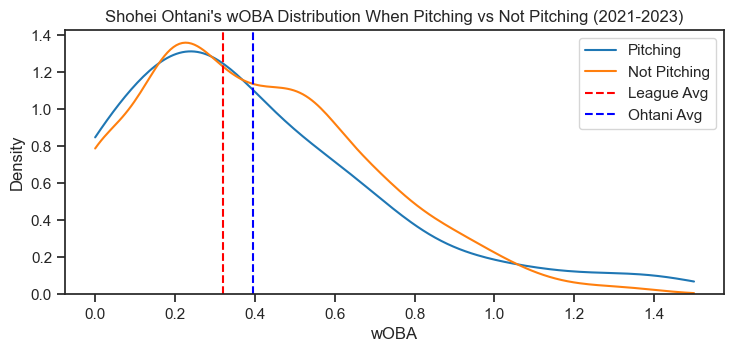

In [70]:
sns.set_style("ticks")
sns.set_context("notebook")

plt.figure(figsize=(17 * 0.5, 7 * 0.49))
sns.kdeplot(
    data=pitching,
    x="woba",
    common_norm=False,  # normalize each group separately
    clip=(0, 1.5),
    label="Pitching",
)
sns.kdeplot(
    data=not_pitching,
    x="woba",
    common_norm=False,  # normalize each group separately
    clip=(0, 1.5),
    label="Not Pitching",
)
plt.axvline(x=0.320, color="red", linestyle="--", linewidth=1.5, label="League Avg")
plt.axvline(
    df["woba"].mean(), color="blue", linestyle="--", linewidth=1.5, label="Ohtani Avg"
)

plt.xlabel("wOBA")
plt.ylabel("Density")
plt.legend()
plt.title("Shohei Ohtani's wOBA Distribution When Pitching vs Not Pitching (2021-2023)")
plt.savefig(
    "./Paper/Data Collection/woba_dist.png",
    dpi=180,
    bbox_inches="tight",
)

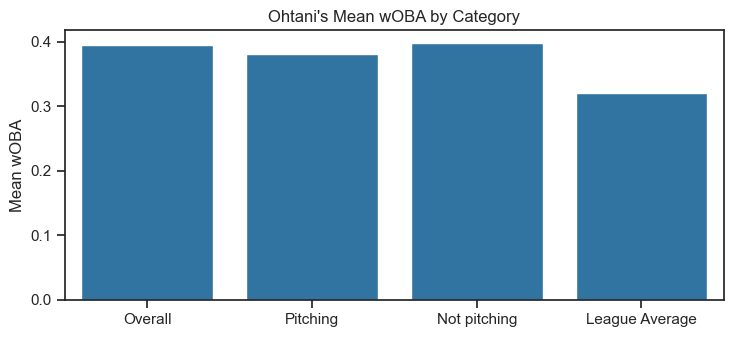

In [10]:
mean_plot_df = pd.DataFrame(
    {
        "category": ["Overall", "Pitching", "Not pitching", "League Average"],
        "value": [
            df["woba"].mean(),
            pitching["woba"].mean(),
            not_pitching["woba"].mean(),
            0.320,
        ],
    }
)

plt.figure(figsize=(17 * 0.5, 7 * 0.5))
sns.barplot(
    mean_plot_df,
    x="category",
    y="value",
)

plt.xlabel("")
plt.ylabel("Mean wOBA")
plt.title("Ohtani's Mean wOBA by Category")

plt.savefig(
    "./Paper/Data Collection/woba_bar_chart.png",
    dpi=180,
    bbox_inches="tight",
)

In [95]:
ga = pd.read_html("./test.html")[0]
ga

,CANDIDATE,PERCENT,VOTES
0,Shawn Harris Democratic,36.8%,"36,756 1,551 ahead"
1,Clayton Fuller Republican,35.3%,35205
2,Colton Moore Republican,12.5%,12445
3,Brian Stover Republican,4.7%,4733
4,Tom Gray Republican,2.7%,2724
5,Jim Davis Democratic,1.4%,1421
6,Nicky Lama Republican,1.3%,1333
7,James Tully Republican,1.2%,1162
8,Beau Brown Republican,0.9%,872
9,Jonathan Hobbs Democratic,0.9%,851


In [98]:
ga.columns = [x.lower() for x in ga.columns]

ga[["name", "party"]] = ga["candidate"].str.rsplit(" ", n=1, expand=True)
ga.drop(columns="candidate", inplace=True)
ga

,percent,votes,name,party
0,36.8%,"36,756 1,551 ahead",Shawn Harris,Democratic
1,35.3%,35205,Clayton Fuller,Republican
2,12.5%,12445,Colton Moore,Republican
3,4.7%,4733,Brian Stover,Republican
4,2.7%,2724,Tom Gray,Republican
5,1.4%,1421,Jim Davis,Democratic
6,1.3%,1333,Nicky Lama,Republican
7,1.2%,1162,James Tully,Republican
8,0.9%,872,Beau Brown,Republican
9,0.9%,851,Jonathan Hobbs,Democratic
